<a href="https://colab.research.google.com/github/karimboyevshaxram97-ux/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
pip install torch

In [6]:
import torch

In [7]:
print(torch.__version__)

2.11.0+cpu


In [8]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


In [19]:
scalar = torch.tensor(5)  # 0D Tensor

print("scalar:", scalar)
print("Shape:", scalar.shape)

scalar: tensor(5)
Shape: torch.Size([])


In [10]:
vector = torch.tensor([1, 2, 3])  # 1D Tensor

print("vector:", vector)

vector: tensor([1, 2, 3])


In [11]:
MATRIX = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])  # 2D Tensor

print("MATRIX:", MATRIX)

MATRIX: tensor([[1, 2, 3],
        [4, 5, 6]])


In [12]:
tensor3d = torch.stack([MATRIX, MATRIX + 10])  # 3D Tensor

print("tensor3d:", tensor3d)

tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])


In [20]:
x = torch.tensor([[1, 2],
                  [3, 4]])

y = torch.tensor([[5, 6],
                  [7, 8]])

# Element-wise addition
print('Addition:', x + y)
print('================')

# Element-wise multiplication
print('Multiplication:', x * y)
print('================')

# Matrix multiplication
print('Matrix @ multiplication:', x @ y)

# x
# [[1, 2],
#  [3, 4]]

# y
# [[5, 6],
#  [7, 8]]

Addition: tensor([[ 6,  8],
        [10, 12]])
Multiplication: tensor([[ 5, 12],
        [21, 32]])
Matrix @ multiplication: tensor([[19, 22],
        [43, 50]])


In [21]:
# Import PyTorch and matplotlib
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [22]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [23]:
# Create weight and bias
weight = 0.7  # weight
bias = 0.3    # bias

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)  # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias

# Linear Regression: y = wx + b
print("X:", X)

print("\n y:", y)

# Split data
train_split = int(0.8 * len(X))  # 10000(100%) data => 8000(80%) train | 2000(20%) test

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

 y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
 

(40, 40, 10, 10)

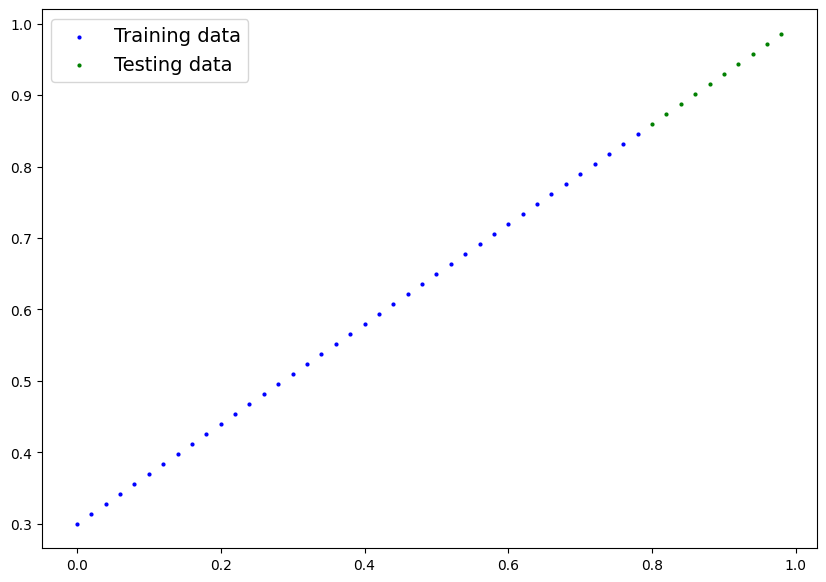

In [24]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data,
                train_labels,
                c='b',
                s=4,
                label='Training data')

    # Plot test data in green
    plt.scatter(test_data,
                test_labels,
                c='g',
                s=4,
                label='Testing data')

    if predictions is not None:
        plt.scatter(test_data,
                    predictions,
                    c='r',
                    s=4,
                    label='Predictions')

    plt.legend(prop={'size': 14})


# CALL
plot_predictions()

In [25]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(
            in_features=1,   # weight
            out_features=1   # Linear => y = wx + b
        )

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set the manual seed when creating the model
# (this isn't always needed but is used for demonstrative purposes,
# try commenting it out and seeing what happens)
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [26]:
# Create loss function
loss_fn = nn.L1Loss()  # Loss Function | MAE => Mean Absolute Error

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),  # optimize newly created model's parameters
                            lr=0.01)  # weight, bias | equal

In [ ]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train()  # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradient optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()  # weight and bias

    ### Testing
    model_1.eval()  # put the model in evaluation mode for testing (inference)

    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}"
        )

In [27]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)

y_preds

tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028],
        [1.5181],
        [1.5334],
        [1.5487],
        [1.5640],
        [1.5793]])

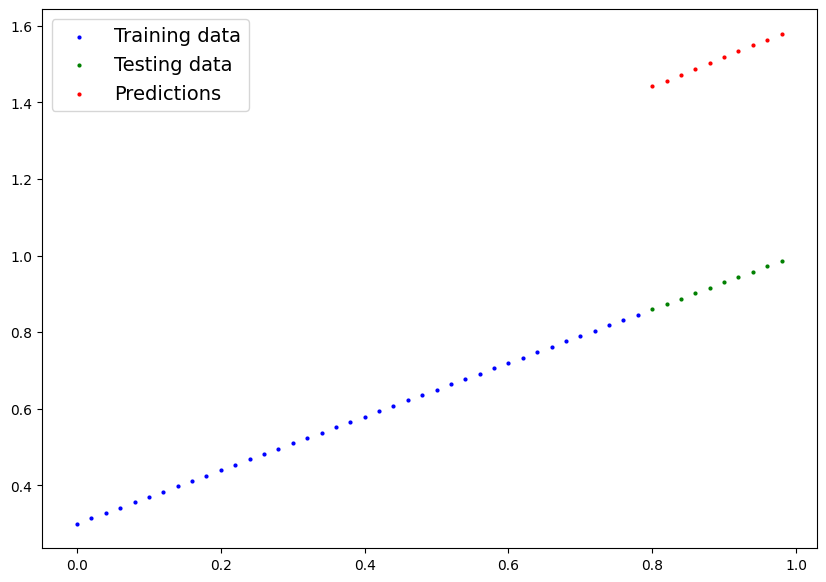

In [28]:
# Put data on the CPU and plot it
plot_predictions(predictions=y_preds)

In [31]:
torch.save(model_1.state_dict(), 'trained_model.pth')

In [32]:

loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load('/content/trained_model.pth'))

loaded_model.eval()

loaded_model

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)